# Lab 5 — Scalable Feature Extraction and Selection for Predictive Maintenance

This notebook is structured to cover the full lab workflow for the NASA C-MAPSS FD001 subset:

1. Download and prepare the dataset  
2. Preprocess the time-series data  
3. Perform feature extraction using **tsfresh**  
4. Apply filter-based feature selection (**variance threshold**, **correlation filtering**, **mutual information**)  
5. Implement a **Genetic Algorithm** using **DEAP** to evolve feature subsets  
6. Train a regression model to predict **Remaining Useful Life (RUL)**  
7. Evaluate the model using relevant metrics  
8. Measure pipeline runtime and optimize speed

**Folder structure**
```text
Cloud Computing/
├─ lab5.ipynb
└─ data/
   └─ raw/
      ├─ train_FD001.txt
      ├─ test_FD001.txt
      └─ RUL_FD001.txt
```

**Notes**
- This notebook keeps `time_cycle` unscaled. Only operating settings and sensor columns are scaled.
- The pipeline uses rolling windows for train/validation and the last window per engine for test.
- The default configuration favors a good balance of correctness and speed. You can tune `WINDOW`, `STRIDE`, `TOP_K_MI`, and GA settings for better performance.
- The lab also asks for a GitHub repo, reproducible run instructions, and a technical write-up in the README. A template generation cell is included at the end.

In [1]:
# Run this once only if your selected notebook kernel does not already have these packages.
# %pip install pandas numpy matplotlib scikit-learn tsfresh deap joblib

In [2]:
import json
import math
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.utilities.dataframe_functions import impute

from deap import algorithms, base, creator, tools

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Imports successful")

Imports successful


## 1) Paths, output folders, and configuration

In [3]:
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

project_root = None
for p in candidate_roots:
    if (p / "data" / "raw" / "train_FD001.txt").exists():
        project_root = p
        break

if project_root is None:
    raise FileNotFoundError(
        "Could not find data/raw/train_FD001.txt. Put the notebook in the project root "
        "or make sure data/raw contains the three FD001 files."
    )

RAW_DIR = project_root / "data" / "raw"
OUTPUT_DIR = project_root / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
FEATURE_DIR = OUTPUT_DIR / "selected_features"
PROCESSED_DIR = OUTPUT_DIR / "processed"

for d in [OUTPUT_DIR, FIG_DIR, METRICS_DIR, FEATURE_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Raw data folder:", RAW_DIR)

WINDOW = 30
STRIDE = 5
TOP_K_MI = 60
CORR_THRESHOLD = 0.95
VAR_THRESHOLD = 0.0
GA_POP_SIZE = 24
GA_N_GEN = 12
GA_CXPB = 0.7
GA_MUTPB = 0.15
GA_ALPHA = 0.10

config = {
    "WINDOW": WINDOW,
    "STRIDE": STRIDE,
    "TOP_K_MI": TOP_K_MI,
    "CORR_THRESHOLD": CORR_THRESHOLD,
    "VAR_THRESHOLD": VAR_THRESHOLD,
    "GA_POP_SIZE": GA_POP_SIZE,
    "GA_N_GEN": GA_N_GEN,
    "GA_CXPB": GA_CXPB,
    "GA_MUTPB": GA_MUTPB,
    "GA_ALPHA": GA_ALPHA,
    "RANDOM_STATE": RANDOM_STATE,
}
config

Project root: c:\Users\ranee\OneDrive\Desktop\University\Winter 2026\Cloud Computing
Raw data folder: c:\Users\ranee\OneDrive\Desktop\University\Winter 2026\Cloud Computing\data\raw


{'WINDOW': 30,
 'STRIDE': 5,
 'TOP_K_MI': 60,
 'CORR_THRESHOLD': 0.95,
 'VAR_THRESHOLD': 0.0,
 'GA_POP_SIZE': 24,
 'GA_N_GEN': 12,
 'GA_CXPB': 0.7,
 'GA_MUTPB': 0.15,
 'GA_ALPHA': 0.1,
 'RANDOM_STATE': 42}

## 2) Load FD001 data

In [4]:
col_names = (
    ["unit_id", "time_cycle", "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train_raw = pd.read_csv(RAW_DIR / "train_FD001.txt", sep=r"\s+", header=None)
test_raw = pd.read_csv(RAW_DIR / "test_FD001.txt", sep=r"\s+", header=None)
rul_raw = pd.read_csv(RAW_DIR / "RUL_FD001.txt", sep=r"\s+", header=None)

train_raw = train_raw.dropna(axis=1, how="all")
test_raw = test_raw.dropna(axis=1, how="all")
rul_raw = rul_raw.dropna(axis=1, how="all")

train_raw.columns = col_names
test_raw.columns = col_names
rul_raw.columns = ["RUL"]

print("Train raw shape:", train_raw.shape)
print("Test raw shape:", test_raw.shape)
print("RUL raw shape:", rul_raw.shape)

display(train_raw.head())
display(test_raw.head())
display(rul_raw.head())

Train raw shape: (20631, 26)
Test raw shape: (13096, 26)
RUL raw shape: (100, 1)


,unit_id,time_cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


,unit_id,time_cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


,RUL
0,112
1,98
2,69
3,82
4,91


## 3) Add RUL to the training set and run basic validation

In [5]:
def add_train_rul(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    max_cycle = out.groupby("unit_id")["time_cycle"].max().rename("max_cycle")
    out = out.merge(max_cycle, on="unit_id", how="left")
    out["RUL"] = out["max_cycle"] - out["time_cycle"]
    out = out.drop(columns=["max_cycle"])
    return out

train = add_train_rul(train_raw)
test = test_raw.copy()
rul = rul_raw.copy()

print("Train shape after adding RUL:", train.shape)
print("Train missing values:", int(train.isna().sum().sum()))
print("Test missing values:", int(test.isna().sum().sum()))
print("RUL missing values:", int(rul.isna().sum().sum()))

display(train[["unit_id", "time_cycle", "RUL"]].head(10))

Train shape after adding RUL: (20631, 27)
Train missing values: 0
Test missing values: 0
RUL missing values: 0


,unit_id,time_cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


## 4) Time-series exploration and validation

In [6]:
setting_cols = [c for c in train.columns if c.startswith("op_setting_")]
sensor_cols = [c for c in train.columns if c.startswith("sensor_")]
scale_cols = setting_cols + sensor_cols

variation_df = pd.DataFrame({
    "column": scale_cols,
    "nunique": [train[c].nunique() for c in scale_cols],
    "std": [train[c].std() for c in scale_cols],
}).sort_values(["nunique", "std"])

display(variation_df.head(15))

,column,nunique,std
2,op_setting_3,1,0.000000e+00
3,sensor_1,1,0.000000e+00
12,sensor_10,1,0.000000e+00
20,sensor_18,1,0.000000e+00
21,sensor_19,1,0.000000e+00
18,sensor_16,1,3.469531e-18
7,sensor_5,1,5.329200e-15
8,sensor_6,2,1.388985e-03
1,op_setting_2,13,2.930621e-04
19,sensor_17,13,1.548763e+00


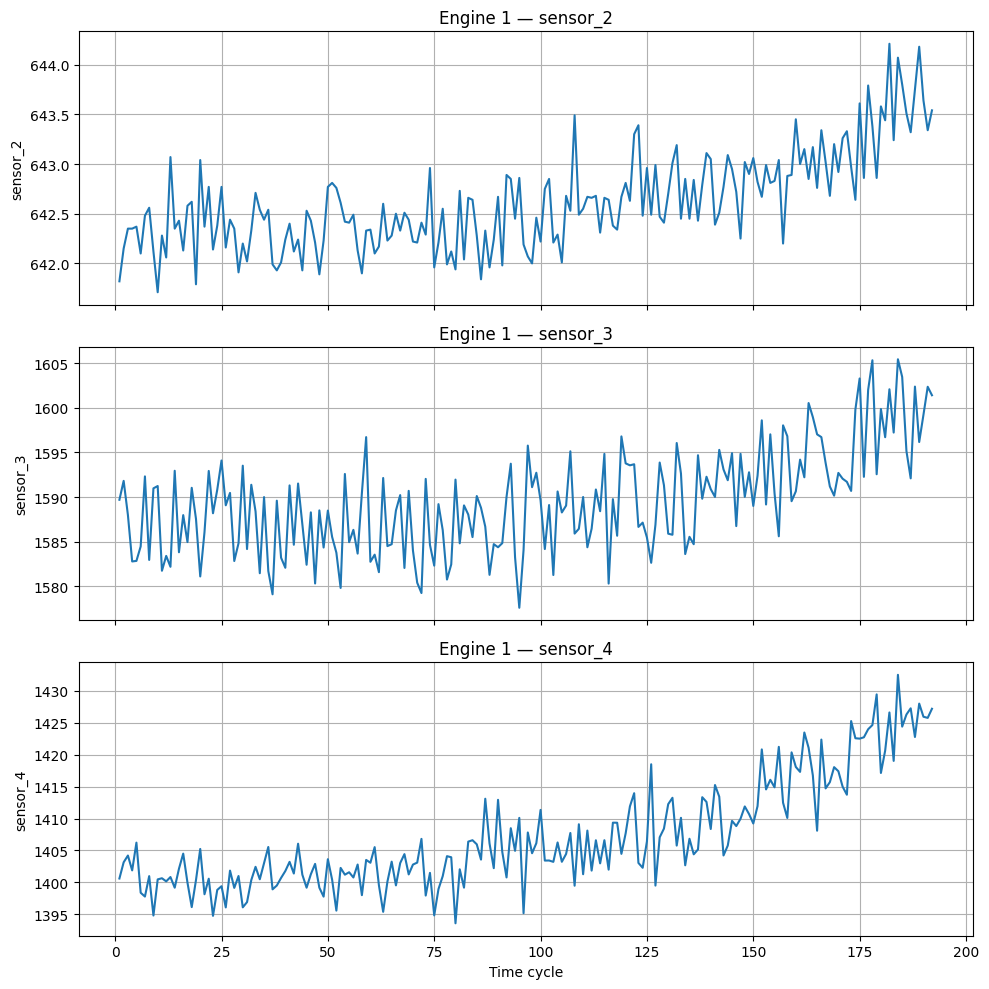

In [7]:
engine_id = 1
plot_cols = ["sensor_2", "sensor_3", "sensor_4"]

engine_df = train[train["unit_id"] == engine_id]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 10), sharex=True)
for ax, col in zip(axes, plot_cols):
    ax.plot(engine_df["time_cycle"], engine_df[col])
    ax.set_title(f"Engine {engine_id} — {col}")
    ax.set_ylabel(col)
    ax.grid(True)
axes[-1].set_xlabel("Time cycle")
plt.tight_layout()
plt.show()

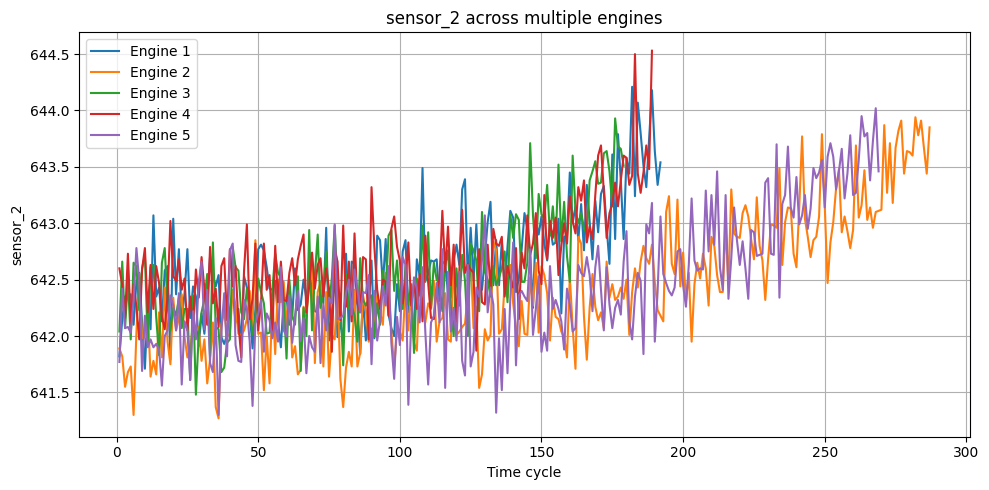

In [8]:
compare_sensor = "sensor_2"
engine_sample = [1, 2, 3, 4, 5]

plt.figure(figsize=(10, 5))
for eid in engine_sample:
    g = train[train["unit_id"] == eid]
    plt.plot(g["time_cycle"], g[compare_sensor], label=f"Engine {eid}")
plt.title(f"{compare_sensor} across multiple engines")
plt.xlabel("Time cycle")
plt.ylabel(compare_sensor)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

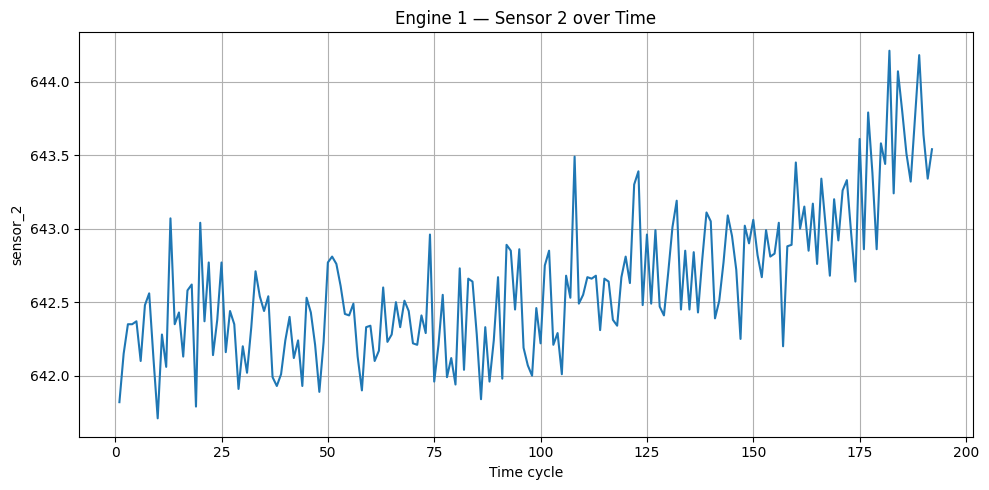

Saved: c:\Users\ranee\OneDrive\Desktop\University\Winter 2026\Cloud Computing\outputs\figures\engine1_sensor2.png


In [9]:
fig_path = FIG_DIR / "engine1_sensor2.png"

plt.figure(figsize=(10, 5))
plt.plot(engine_df["time_cycle"], engine_df["sensor_2"])
plt.title("Engine 1 — Sensor 2 over Time")
plt.xlabel("Time cycle")
plt.ylabel("sensor_2")
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

## 5) Split by engine ID to avoid leakage
The split is done at the **engine level**, not the row level.

In [10]:
def split_engine_ids(unit_ids, val_size=0.2, random_state=42):
    unit_ids = np.array(sorted(unit_ids))
    rng = np.random.default_rng(random_state)
    shuffled = unit_ids.copy()
    rng.shuffle(shuffled)
    n_val = max(1, int(len(shuffled) * val_size))
    val_ids = np.sort(shuffled[:n_val])
    train_ids = np.sort(shuffled[n_val:])
    return train_ids, val_ids

train_engine_ids, val_engine_ids = split_engine_ids(
    train["unit_id"].unique(),
    val_size=0.2,
    random_state=RANDOM_STATE,
)

train_rows = train[train["unit_id"].isin(train_engine_ids)].copy()
val_rows = train[train["unit_id"].isin(val_engine_ids)].copy()
test_rows = test.copy()

print("Train engines:", len(train_engine_ids), "Rows:", train_rows.shape[0])
print("Val engines:", len(val_engine_ids), "Rows:", val_rows.shape[0])
print("Test engines:", test_rows["unit_id"].nunique(), "Rows:", test_rows.shape[0])

Train engines: 80 Rows: 16779
Val engines: 20 Rows: 3852
Test engines: 100 Rows: 13096


## 6) Scale operating settings and sensors only
Do **not** scale `unit_id`, `time_cycle`, or `RUL`.

In [11]:
scaler = StandardScaler()

train_scaled = train_rows.copy()
val_scaled = val_rows.copy()
test_scaled = test_rows.copy()

train_scaled[scale_cols] = scaler.fit_transform(train_scaled[scale_cols])
val_scaled[scale_cols] = scaler.transform(val_scaled[scale_cols])
test_scaled[scale_cols] = scaler.transform(test_scaled[scale_cols])

display(train_scaled[["unit_id", "time_cycle", "RUL"] + scale_cols[:3]].head())

,unit_id,time_cycle,RUL,op_setting_1,op_setting_2,op_setting_3
0,1,1,191,-0.310576,-1.382102,0.0
1,1,2,190,0.878819,-1.040143,0.0
2,1,3,189,-1.957429,1.011611,0.0
3,1,4,188,0.329867,-0.014266,0.0
4,1,5,187,-0.859527,-0.698184,0.0


## 7) Build windowed datasets
- Train/validation: rolling windows with the current cycle's RUL as the target  
- Test: last available window per engine, labeled using `RUL_FD001.txt`

In [12]:
def build_rolling_windows(df: pd.DataFrame, feature_cols, window=30, stride=5):
    window_tables = []
    target_rows = []

    df = df.sort_values(["unit_id", "time_cycle"]).copy()

    for unit_id, g in df.groupby("unit_id"):
        g = g.reset_index(drop=True)

        if len(g) < window:
            continue

        for end_idx in range(window - 1, len(g), stride):
            cutoff_cycle = int(g.loc[end_idx, "time_cycle"])
            target_rul = float(g.loc[end_idx, "RUL"])

            w = g.loc[end_idx - window + 1 : end_idx, ["time_cycle"] + feature_cols].copy()
            window_id = f"{unit_id}_{cutoff_cycle}"
            w.insert(0, "window_id", window_id)

            window_tables.append(w)
            target_rows.append({
                "window_id": window_id,
                "unit_id": unit_id,
                "cutoff_cycle": cutoff_cycle,
                "RUL": target_rul,
            })

    windows_df = pd.concat(window_tables, ignore_index=True)
    targets_df = pd.DataFrame(target_rows)
    return windows_df, targets_df


def build_test_last_windows(df: pd.DataFrame, rul_df: pd.DataFrame, feature_cols, window=30):
    rul_map = rul_df.copy()
    rul_map["unit_id"] = np.arange(1, len(rul_map) + 1)

    window_tables = []
    target_rows = []

    df = df.sort_values(["unit_id", "time_cycle"]).copy()

    for unit_id, g in df.groupby("unit_id"):
        g = g.reset_index(drop=True)

        start_idx = max(0, len(g) - window)
        cutoff_cycle = int(g.loc[len(g) - 1, "time_cycle"])
        target_rul = float(rul_map.loc[rul_map["unit_id"] == unit_id, "RUL"].iloc[0])

        w = g.loc[start_idx:, ["time_cycle"] + feature_cols].copy()
        window_id = f"{unit_id}_{cutoff_cycle}"
        w.insert(0, "window_id", window_id)

        window_tables.append(w)
        target_rows.append({
            "window_id": window_id,
            "unit_id": unit_id,
            "cutoff_cycle": cutoff_cycle,
            "RUL": target_rul,
        })

    windows_df = pd.concat(window_tables, ignore_index=True)
    targets_df = pd.DataFrame(target_rows)
    return windows_df, targets_df

In [13]:
tsfresh_feature_cols = scale_cols

train_windows, train_targets = build_rolling_windows(
    train_scaled,
    tsfresh_feature_cols,
    window=WINDOW,
    stride=STRIDE,
)

val_windows, val_targets = build_rolling_windows(
    val_scaled,
    tsfresh_feature_cols,
    window=WINDOW,
    stride=STRIDE,
)

test_windows, test_targets = build_test_last_windows(
    test_scaled,
    rul,
    tsfresh_feature_cols,
    window=WINDOW,
)

print("train_windows:", train_windows.shape, "train_targets:", train_targets.shape)
print("val_windows:", val_windows.shape, "val_targets:", val_targets.shape)
print("test_windows:", test_windows.shape, "test_targets:", test_targets.shape)

print("Any duplicate train window ids?", train_targets["window_id"].duplicated().any())
display(train_targets.head())

train_windows: (87690, 26) train_targets: (2923, 4)
val_windows: (19890, 26) val_targets: (663, 4)
test_windows: (3000, 26) test_targets: (100, 4)
Any duplicate train window ids? False


,window_id,unit_id,cutoff_cycle,RUL
0,1_30,1,30,162.0
1,1_35,1,35,157.0
2,1_40,1,40,152.0
3,1_45,1,45,147.0
4,1_50,1,50,142.0


## 8) Extract tsfresh features
This is usually the slowest stage. `MinimalFCParameters()` is used here to keep the pipeline practical and fast.

In [14]:
runtime_log = {}

t0 = time.perf_counter()

fc_params = MinimalFCParameters()

X_train_tsfresh = extract_features(
    train_windows,
    column_id="window_id",
    column_sort="time_cycle",
    default_fc_parameters=fc_params,
    n_jobs=1,
)
impute(X_train_tsfresh)

X_val_tsfresh = extract_features(
    val_windows,
    column_id="window_id",
    column_sort="time_cycle",
    default_fc_parameters=fc_params,
    n_jobs=1,
)
impute(X_val_tsfresh)

X_test_tsfresh = extract_features(
    test_windows,
    column_id="window_id",
    column_sort="time_cycle",
    default_fc_parameters=fc_params,
    n_jobs=1,
)
impute(X_test_tsfresh)

runtime_log["tsfresh_extraction_seconds"] = time.perf_counter() - t0

print("X_train_tsfresh:", X_train_tsfresh.shape)
print("X_val_tsfresh:", X_val_tsfresh.shape)
print("X_test_tsfresh:", X_test_tsfresh.shape)
print("tsfresh time (sec):", round(runtime_log["tsfresh_extraction_seconds"], 2))

Feature Extraction: 100%|██████████| 2400/2400 [00:00<00:00, 3492.09it/s]

X_train_tsfresh: (2923, 240)
X_val_tsfresh: (663, 240)
X_test_tsfresh: (100, 240)
tsfresh time (sec): 26.19


In [15]:
X_train_tsfresh = X_train_tsfresh.reset_index().rename(columns={"index": "window_id"})
X_val_tsfresh = X_val_tsfresh.reset_index().rename(columns={"index": "window_id"})
X_test_tsfresh = X_test_tsfresh.reset_index().rename(columns={"index": "window_id"})

train_features = train_targets.merge(X_train_tsfresh, on="window_id", how="inner")
val_features = val_targets.merge(X_val_tsfresh, on="window_id", how="inner")
test_features = test_targets.merge(X_test_tsfresh, on="window_id", how="inner")

print("train_features:", train_features.shape)
print("val_features:", val_features.shape)
print("test_features:", test_features.shape)

display(train_features.head())

train_features: (2923, 244)
val_features: (663, 244)
test_features: (100, 244)


,window_id,unit_id,cutoff_cycle,RUL,op_setting_1__sum_values,op_setting_1__median,op_setting_1__mean,op_setting_1__length,op_setting_1__standard_deviation,op_setting_1__variance,...,sensor_21__sum_values,sensor_21__median,sensor_21__mean,sensor_21__length,sensor_21__standard_deviation,sensor_21__variance,sensor_21__root_mean_square,sensor_21__maximum,sensor_21__absolute_maximum,sensor_21__minimum
0,1_30,1,30,162.0,-7.304446,-0.150465,-0.243482,30.0,0.989264,0.978644,...,26.497711,0.841193,0.883257,30.0,0.477922,0.228409,1.004267,1.743357,1.743357,-0.129233
1,1_35,1,35,157.0,-5.566101,0.101138,-0.185537,30.0,0.986525,0.973231,...,26.002351,0.817209,0.866745,30.0,0.530600,0.281536,1.016259,1.938918,1.938918,-0.129233
2,1_40,1,40,152.0,-3.919247,0.009646,-0.130642,30.0,0.884442,0.782238,...,27.466292,0.841193,0.915543,30.0,0.529022,0.279864,1.057395,1.938918,1.938918,-0.129233
3,1_45,1,45,147.0,-4.330961,-0.013227,-0.144365,30.0,0.908145,0.824727,...,28.857359,0.985096,0.961912,30.0,0.508593,0.258667,1.088091,1.938918,1.938918,-0.051746
4,1_50,1,50,142.0,-4.147977,-0.013227,-0.138266,30.0,0.837095,0.700728,...,30.086073,1.039983,1.002869,30.0,0.514355,0.264561,1.127079,1.938918,1.938918,-0.051746


## 9) Filter-based feature selection
The lab explicitly asks for:
1. Variance threshold  
2. Correlation filtering  
3. Mutual information

In [16]:
meta_cols = ["window_id", "unit_id", "cutoff_cycle", "RUL"]

X_train_full = train_features.drop(columns=meta_cols).copy()
X_val_full = val_features.drop(columns=meta_cols).copy()
X_test_full = test_features.drop(columns=meta_cols).copy()

y_train = train_features["RUL"].copy()
y_val = val_features["RUL"].copy()
y_test = test_features["RUL"].copy()

common_cols = sorted(set(X_train_full.columns) & set(X_val_full.columns) & set(X_test_full.columns))
X_train_full = X_train_full[common_cols]
X_val_full = X_val_full[common_cols]
X_test_full = X_test_full[common_cols]

print("Initial feature count:", X_train_full.shape[1])

Initial feature count: 240


In [17]:
t0 = time.perf_counter()

vt = VarianceThreshold(threshold=VAR_THRESHOLD)
X_train_vt = pd.DataFrame(
    vt.fit_transform(X_train_full),
    columns=X_train_full.columns[vt.get_support()],
    index=X_train_full.index,
)
X_val_vt = X_val_full[X_train_vt.columns].copy()
X_test_vt = X_test_full[X_train_vt.columns].copy()

runtime_log["variance_threshold_seconds"] = time.perf_counter() - t0

print("After variance threshold:", X_train_vt.shape[1])

After variance threshold: 151


In [18]:
t0 = time.perf_counter()

corr_matrix = X_train_vt.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

X_train_corr = X_train_vt.drop(columns=to_drop_corr)
X_val_corr = X_val_vt.drop(columns=to_drop_corr)
X_test_corr = X_test_vt.drop(columns=to_drop_corr)

runtime_log["correlation_filter_seconds"] = time.perf_counter() - t0

print("Dropped by correlation filter:", len(to_drop_corr))
print("After correlation filter:", X_train_corr.shape[1])

Dropped by correlation filter: 85
After correlation filter: 66


In [19]:
t0 = time.perf_counter()

mi_scores = mutual_info_regression(X_train_corr, y_train, random_state=RANDOM_STATE)
mi_df = (
    pd.DataFrame({"feature": X_train_corr.columns, "mi_score": mi_scores})
    .sort_values("mi_score", ascending=False)
    .reset_index(drop=True)
)

top_k = min(TOP_K_MI, len(mi_df))
selected_mi_features = mi_df.head(top_k)["feature"].tolist()

X_train_mi = X_train_corr[selected_mi_features].copy()
X_val_mi = X_val_corr[selected_mi_features].copy()
X_test_mi = X_test_corr[selected_mi_features].copy()

runtime_log["mutual_information_seconds"] = time.perf_counter() - t0

print("After mutual information top-k:", X_train_mi.shape[1])
display(mi_df.head(15))

After mutual information top-k: 60


,feature,mi_score
0,sensor_11__maximum,0.584166
1,sensor_15__maximum,0.458866
2,sensor_20__minimum,0.453808
3,sensor_17__absolute_maximum,0.448368
4,sensor_17__maximum,0.442281
5,sensor_21__maximum,0.409972
6,sensor_2__maximum,0.407682
7,sensor_21__minimum,0.406185
8,sensor_3__maximum,0.391354
9,sensor_13__maximum,0.360828


## 10) Baseline models before GA
This gives you a comparison point before the genetic algorithm.

In [20]:
def regression_metrics(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

baseline_models = {
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

baseline_results = []

for name, model in baseline_models.items():
    t0 = time.perf_counter()
    model.fit(X_train_mi, y_train)
    pred_val = model.predict(X_val_mi)
    elapsed = time.perf_counter() - t0

    metrics = regression_metrics(y_val, pred_val)
    metrics["model"] = name
    metrics["fit_predict_seconds"] = elapsed
    metrics["n_features"] = X_train_mi.shape[1]
    baseline_results.append(metrics)

baseline_df = pd.DataFrame(baseline_results).sort_values("rmse")
display(baseline_df)

baseline_best_name = baseline_df.iloc[0]["model"]
baseline_best_model = clone(baseline_models[baseline_best_name])
print("Best baseline model:", baseline_best_name)

,rmse,mae,r2,model,fit_predict_seconds,n_features
1,31.782292,22.555588,0.632437,RandomForest,2.606581,60
0,32.001877,22.933567,0.627341,GradientBoosting,5.423897,60


Best baseline model: RandomForest


## 11) Genetic Algorithm with DEAP
Fitness = validation RMSE + penalty on the fraction of selected features.

In [21]:
if not hasattr(creator, "FitnessMinLab5"):
    creator.create("FitnessMinLab5", base.Fitness, weights=(-1.0,))
if not hasattr(creator, "IndividualLab5"):
    creator.create("IndividualLab5", list, fitness=creator.FitnessMinLab5)

ga_feature_names = list(X_train_mi.columns)
n_ga_features = len(ga_feature_names)

X_train_ga = X_train_mi.copy()
X_val_ga = X_val_mi.copy()

ga_model_template = GradientBoostingRegressor(random_state=RANDOM_STATE)

def evaluate_individual(individual):
    selected_idx = [i for i, bit in enumerate(individual) if bit == 1]
    if len(selected_idx) == 0:
        return (1e9,)

    selected_cols = [ga_feature_names[i] for i in selected_idx]

    model = clone(ga_model_template)
    model.fit(X_train_ga[selected_cols], y_train)
    pred = model.predict(X_val_ga[selected_cols])

    rmse = float(np.sqrt(mean_squared_error(y_val, pred)))
    penalty = GA_ALPHA * (len(selected_cols) / n_ga_features)
    score = rmse + penalty
    return (score,)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.IndividualLab5, toolbox.attr_bool, n=n_ga_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate_individual)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

print("GA feature count:", n_ga_features)

GA feature count: 60


In [22]:
t0 = time.perf_counter()

population = toolbox.population(n=GA_POP_SIZE)
halloffame = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values[0])
stats.register("min", np.min)
stats.register("avg", np.mean)

population, logbook = algorithms.eaSimple(
    population,
    toolbox,
    cxpb=GA_CXPB,
    mutpb=GA_MUTPB,
    ngen=GA_N_GEN,
    stats=stats,
    halloffame=halloffame,
    verbose=True,
)

runtime_log["ga_seconds"] = time.perf_counter() - t0

best_individual = halloffame[0]
ga_selected_features = [ga_feature_names[i] for i, bit in enumerate(best_individual) if bit == 1]

print("GA selected feature count:", len(ga_selected_features))
print("GA runtime (sec):", round(runtime_log["ga_seconds"], 2))
ga_selected_features[:20]

gen	nevals	min    	avg    
0  	24    	31.3688	33.1286
1  	19    	30.5185	32.1496
2  	15    	30.3968	31.6304
3  	21    	30.3968	31.0719
4  	16    	29.9059	30.836 
5  	17    	29.9059	30.6092
6  	17    	29.9059	30.2587
7  	14    	29.9059	30.191 
8  	20    	29.9059	30.0612
9  	20    	29.9059	30.0144
10 	21    	29.9059	29.9174
11 	18    	29.9059	29.9059
12 	16    	29.9059	29.9059
GA selected feature count: 30
GA runtime (sec): 963.24


['sensor_11__maximum',
 'sensor_15__maximum',
 'sensor_2__maximum',
 'sensor_13__maximum',
 'sensor_20__maximum',
 'sensor_7__maximum',
 'sensor_2__minimum',
 'sensor_20__absolute_maximum',
 'sensor_15__minimum',
 'sensor_8__absolute_maximum',
 'sensor_21__root_mean_square',
 'sensor_13__absolute_maximum',
 'sensor_17__root_mean_square',
 'sensor_3__root_mean_square',
 'sensor_11__standard_deviation',
 'sensor_9__standard_deviation',
 'sensor_11__absolute_maximum',
 'sensor_12__absolute_maximum',
 'sensor_7__absolute_maximum',
 'sensor_14__variance']

## 12) Train the final model and evaluate
We compare:
- best baseline model using MI-filtered features
- final model using GA-selected features

In [23]:
# Baseline best on MI-filtered features
t0 = time.perf_counter()
baseline_best_model.fit(X_train_mi, y_train)
baseline_val_pred = baseline_best_model.predict(X_val_mi)
baseline_test_pred = baseline_best_model.predict(X_test_mi)
runtime_log["baseline_best_fit_predict_seconds"] = time.perf_counter() - t0

baseline_val_metrics = regression_metrics(y_val, baseline_val_pred)
baseline_test_metrics = regression_metrics(y_test, baseline_test_pred)

# Final GA model
final_model = GradientBoostingRegressor(random_state=RANDOM_STATE)

t0 = time.perf_counter()
final_model.fit(X_train_mi[ga_selected_features], y_train)
final_val_pred = final_model.predict(X_val_mi[ga_selected_features])
final_test_pred = final_model.predict(X_test_mi[ga_selected_features])
runtime_log["final_ga_fit_predict_seconds"] = time.perf_counter() - t0

final_val_metrics = regression_metrics(y_val, final_val_pred)
final_test_metrics = regression_metrics(y_test, final_test_pred)

comparison_df = pd.DataFrame([
    {
        "pipeline": f"Baseline ({baseline_best_name})",
        "split": "Validation",
        **baseline_val_metrics,
        "n_features": X_train_mi.shape[1],
    },
    {
        "pipeline": f"Baseline ({baseline_best_name})",
        "split": "Test",
        **baseline_test_metrics,
        "n_features": X_train_mi.shape[1],
    },
    {
        "pipeline": "GA-selected (GradientBoosting)",
        "split": "Validation",
        **final_val_metrics,
        "n_features": len(ga_selected_features),
    },
    {
        "pipeline": "GA-selected (GradientBoosting)",
        "split": "Test",
        **final_test_metrics,
        "n_features": len(ga_selected_features),
    },
])

display(comparison_df)

,pipeline,split,rmse,mae,r2,n_features
0,Baseline (RandomForest),Validation,31.782292,22.555588,0.632437,60
1,Baseline (RandomForest),Test,32.006996,23.729200,0.406760,60
2,GA-selected (GradientBoosting),Validation,29.855936,22.019433,0.675644,30
3,GA-selected (GradientBoosting),Test,31.737448,24.126086,0.416710,30


## 13) Save outputs for the lab report / GitHub submission

In [24]:
runtime_log["total_pipeline_seconds"] = float(sum(runtime_log.values()))

metrics_summary = {
    "config": config,
    "feature_counts": {
        "initial_tsfresh": int(X_train_full.shape[1]),
        "after_variance_threshold": int(X_train_vt.shape[1]),
        "after_correlation_filter": int(X_train_corr.shape[1]),
        "after_mutual_information": int(X_train_mi.shape[1]),
        "after_ga": int(len(ga_selected_features)),
    },
    "baseline_best_model": baseline_best_name,
    "baseline_validation_metrics": baseline_val_metrics,
    "baseline_test_metrics": baseline_test_metrics,
    "ga_validation_metrics": final_val_metrics,
    "ga_test_metrics": final_test_metrics,
    "runtime_seconds": runtime_log,
}

with open(METRICS_DIR / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2)

comparison_df.to_csv(METRICS_DIR / "metrics_comparison.csv", index=False)
mi_df.to_csv(METRICS_DIR / "mutual_information_scores.csv", index=False)

pd.DataFrame({"selected_feature": ga_selected_features}).to_csv(
    FEATURE_DIR / "ga_selected_features.csv",
    index=False,
)

with open(FEATURE_DIR / "ga_selected_features.txt", "w", encoding="utf-8") as f:
    for feat in ga_selected_features:
        f.write(f"{feat}\n")

train_features.to_csv(PROCESSED_DIR / "train_tsfresh_features.csv", index=False)
val_features.to_csv(PROCESSED_DIR / "val_tsfresh_features.csv", index=False)
test_features.to_csv(PROCESSED_DIR / "test_tsfresh_features.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)
print("JSON:", METRICS_DIR / "metrics_summary.json")
print("CSV:", METRICS_DIR / "metrics_comparison.csv")
print("Selected features:", FEATURE_DIR / "ga_selected_features.csv")

Saved outputs to: c:\Users\ranee\OneDrive\Desktop\University\Winter 2026\Cloud Computing\outputs
JSON: c:\Users\ranee\OneDrive\Desktop\University\Winter 2026\Cloud Computing\outputs\metrics\metrics_summary.json
CSV: c:\Users\ranee\OneDrive\Desktop\University\Winter 2026\Cloud Computing\outputs\metrics\metrics_comparison.csv
Selected features: c:\Users\ranee\OneDrive\Desktop\University\Winter 2026\Cloud Computing\outputs\selected_features\ga_selected_features.csv


## 14) Final summary table for the report

In [25]:
summary_rows = [
    ["Initial tsfresh features", X_train_full.shape[1]],
    ["After variance threshold", X_train_vt.shape[1]],
    ["After correlation filter", X_train_corr.shape[1]],
    ["After mutual information", X_train_mi.shape[1]],
    ["After GA", len(ga_selected_features)],
]

summary_df = pd.DataFrame(summary_rows, columns=["stage", "feature_count"])
display(summary_df)
display(comparison_df)

,stage,feature_count
0,Initial tsfresh features,240
1,After variance threshold,151
2,After correlation filter,66
3,After mutual information,60
4,After GA,30


,pipeline,split,rmse,mae,r2,n_features
0,Baseline (RandomForest),Validation,31.782292,22.555588,0.632437,60
1,Baseline (RandomForest),Test,32.006996,23.729200,0.406760,60
2,GA-selected (GradientBoosting),Validation,29.855936,22.019433,0.675644,30
3,GA-selected (GradientBoosting),Test,31.737448,24.126086,0.416710,30


## 15) Optional: generate a README template and requirements file
The lab deliverables also ask for:
- GitHub repository with the full pipeline  
- technical report in the README  
- reproducible instructions to run experiments

In [26]:
readme_text = f'''
# Lab 5 — Scalable Feature Extraction and Selection for Predictive Maintenance

## Objective
Build a reproducible pipeline on the NASA C-MAPSS FD001 dataset to predict Remaining Useful Life (RUL) using:
- tsfresh feature extraction
- filter-based feature selection
- DEAP genetic algorithm
- regression modeling

## Project structure
```text
.
├─ data/raw/
├─ outputs/
│  ├─ figures/
│  ├─ metrics/
│  ├─ processed/
│  └─ selected_features/
└─ lab5.ipynb
```

## Dataset
Files used:
- train_FD001.txt
- test_FD001.txt
- RUL_FD001.txt

## Pipeline
1. Load and validate FD001
2. Add RUL to the training split
3. Explore sensor behavior
4. Split by engine ID
5. Scale operating settings and sensor columns
6. Build fixed-length windows
7. Extract tsfresh features with MinimalFCParameters
8. Apply variance threshold
9. Apply correlation filtering
10. Rank with mutual information
11. Run DEAP GA on the reduced feature set
12. Train regression model
13. Evaluate with RMSE, MAE, and R²
14. Save metrics, features, and processed outputs

## Current configuration
```json
{json.dumps(config, indent=2)}
```

## Best results from this run
- Best baseline model: {baseline_best_name}
- Baseline validation RMSE: {baseline_val_metrics["rmse"]:.4f}
- Baseline test RMSE: {baseline_test_metrics["rmse"]:.4f}
- GA validation RMSE: {final_val_metrics["rmse"]:.4f}
- GA test RMSE: {final_test_metrics["rmse"]:.4f}
- Selected features after GA: {len(ga_selected_features)}

## How to run
1. Put the FD001 files in `data/raw/`
2. Open `lab5.ipynb`
3. Run all cells from top to bottom
4. Check saved outputs in `outputs/`

## Submission checklist
- [ ] GitHub repo created
- [ ] Notebook committed
- [ ] README committed
- [ ] outputs/metrics files saved
- [ ] outputs/selected_features files saved
- [ ] reproducible run instructions included
'''.strip()

(project_root / "README.md").write_text(readme_text, encoding="utf-8")

requirements_text = '''
pandas
numpy
matplotlib
scikit-learn
tsfresh
deap
joblib
'''.strip()

(project_root / "requirements.txt").write_text(requirements_text, encoding="utf-8")

print("Generated:")
print(project_root / "README.md")
print(project_root / "requirements.txt")

Generated:
c:\Users\ranee\OneDrive\Desktop\University\Winter 2026\Cloud Computing\README.md
c:\Users\ranee\OneDrive\Desktop\University\Winter 2026\Cloud Computing\requirements.txt
